# Demonstartor Model 2
## Controlled Pendulum

**Modelica Models**

In [162]:
from path import Path

root = Path(r'/home/flo/repos/SystemSimulation/demos/ControlledPendulum/')
pkg_dir = Path(root / "ControlledPendulum")
pkg_str = str(root / "ControlledPendulum" / "package.mo")
pkg_name = "ControlledPendulum"

model_names = Path(pkg_dir).files("*.mo")
model_names = [m.stem for m in model_names if m.stem != "package"]

for model_name in model_names:
    print(f"Found model: {model_name}")

Found model: PID_Cont
Found model: PIDController
Found model: DemoModel
Found model: Drive
Found model: Pendulum
Found model: ReferenceTrajectory
Found model: Sensor


**Helper Functions for FMU Creation**

In [163]:
from OMPython import ModelicaSystem
import shutil

def create_modelica_system(model_name):
    model = ModelicaSystem(pkg_str, model_name, verbose=True)
    return model

def create_fmu(model: ModelicaSystem, fmuType="cs"):
    model.buildModel()
    fmu_path = model.convertMo2Fmu(fmuType=fmuType)
    return fmu_path

def move_file(src_path, dst_path):
    shutil.move(src_path, dst_path)

**Create FMUs for the Models**

In [164]:
from pyfmi import load_fmu

fmu_path_dict = {}
num_models = len(model_names)
for model_name, i in zip(model_names, range(len(model_names))):
    print(60 * "-")
    print(f"Creating FMU {i + 1}/{num_models}: {model_name}")
    
    # Create Modelica model
    model = create_modelica_system(pkg_name + "." + model_name)
    
    # Create FMU
    fmu_path = create_fmu(model)
    
    # Define destination path and move FMU there
    dest_path = str(root / "FMUs" / (model_name + ".fmu"))
    
    # Move FMU to destination path
    move_file(fmu_path, dest_path)

    # Add to dictionary
    fmu_path_dict[model_name] = dest_path

------------------------------------------------------------
Creating FMU 1/7: PID_Cont
[/home/flo/repos/SystemSimulation/demos/ControlledPendulum/ControlledPendulum/package.mo:1:1-2:23:writable] Warning: PID_Discrete was referenced in the package.order file, but was not found in package.mo, PID_Discrete/package.mo or PID_Discrete.mo.

Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


------------------------------------------------------------
Creating FMU 2/7: PIDController
[/home/flo/repos/SystemSimulation/demos/ControlledPendulum/ControlledPendulum/package.mo:1:1-2:23:writable] Warning: PID_Discrete was referenced in the package.order file, but was not found in package.mo, PID_Discrete/package.mo or PID_Discrete.mo.

Notification: Automatically loaded package Com

In [175]:
ref_fmu = load_fmu(fmu_path_dict["ReferenceTrajectory"])
sensor_ref_fmu = load_fmu(fmu_path_dict["Sensor"])
sensor_state_fmu = load_fmu(fmu_path_dict["Sensor"])
pid_fmu = load_fmu(fmu_path_dict["PID_Cont"])
drive_fmu = load_fmu(fmu_path_dict["Drive"])
pendulum_fmu = load_fmu(fmu_path_dict["Pendulum"])

fmu_list = [ref_fmu, sensor_ref_fmu, sensor_state_fmu, pid_fmu, drive_fmu, pendulum_fmu]

t = 0.0
dt = 0.001
tf = 10.0
h = dt  # step size

for fmu in fmu_list:
    fmu.reset()
    fmu.setup_experiment(start_time=t)
    fmu.initialize()

pid_fmu.set("uMin", -1); pid_fmu.set("uMax", 1)
print(f"PID initialized with uMin={pid_fmu.get('uMin')[0]}, uMax={pid_fmu.get('uMax')[0]}")

PID initialized with uMin=-1.0, uMax=1.0


**Co-Simulation Loop**

In [176]:
# Initialize logging arrays
ts = []
q_ref_log, q_state_log, omega_state_log = [], [], []
U_ref_log, U_state_log = [], []

while t < tf - 1e-9:
    # 1) Read the current outputs
    ref_fmu.do_step(current_t=t, step_size=h)
    q_ref = float(ref_fmu.get("q_ref")[0])

    # 2) Read plant state at current time
    q_state = float(pendulum_fmu.get("q_state")[0])
    omega_state = float(pendulum_fmu.get("omega_state")[0])

    # 3) Sensors: set inputs -> step -> read outputs
    sensor_ref_fmu.set("q", q_ref)
    sensor_state_fmu.set("q", q_state)
    sensor_ref_fmu.do_step(current_t=t, step_size=h)
    sensor_state_fmu.do_step(current_t=t, step_size=h)
    U_ref = float(sensor_ref_fmu.get("U_q")[0])
    U_state = float(sensor_state_fmu.get("U_q")[0])

    error = U_ref - U_state

    # 4) PID: useses sensor voltages as inputs
    pid_fmu.set("y", U_state)
    pid_fmu.set("ref", U_ref)
    pid_fmu.do_step(current_t=t, step_size=h)
    u_control = float(pid_fmu.get("u")[0])

    # 5) Drive
    drive_fmu.set("u_control", u_control)
    drive_fmu.set("omega", omega_state)
    drive_fmu.do_step(current_t=t, step_size=h)
    torque = float(drive_fmu.get("torque")[0])

    # 6) Pendulum
    pendulum_fmu.set("torque", torque)
    pendulum_fmu.do_step(current_t=t, step_size=h)

    # Logging
    ts.append(t)
    q_ref_log.append(q_ref)
    q_state_log.append(q_state)
    omega_state_log.append(omega_state)
    U_ref_log.append(U_ref)
    U_state_log.append(U_state)

    # Increase time
    t += h

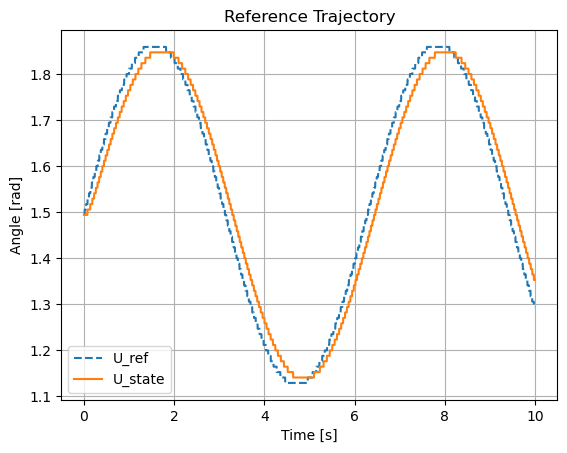

In [177]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(ts, U_ref_log, label="U_ref", linestyle="--")
plt.plot(ts, U_state_log, label="U_state")
plt.xlabel("Time [s]")
plt.ylabel("Angle [rad]")
plt.title("Reference Trajectory")
plt.legend()
plt.grid()